In [12]:
import torch
import matplotlib.pyplot as plt

# Parameters
N = 100  # number of monomers
bond_length = 1.0
loop_rest_length = 0.2
loop_strength = 10.0
num_loops = 3
num_steps = 100
lr = 0.05

# Create a random walk polymer
coords = torch.randn(N, 3)
coords = torch.cumsum(coords / coords.norm(dim=1, keepdim=True), dim=0)
coords.requires_grad_(True)

# Define adjacent bonds
bond_idx = [(i, i+1) for i in range(N-1)]

# Define long-range loops
loop_idx = [(i, i+10) for i in range(0, N-10, N // num_loops)]

# Optimizer
optimizer = torch.optim.Adam([coords], lr=lr)




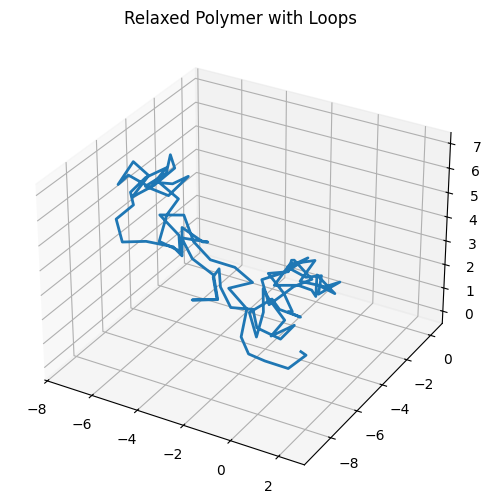

In [13]:
for step in range(num_steps):
    optimizer.zero_grad()

    # Bond energy (adjacent)
    b_i, b_j = zip(*bond_idx)
    b_dist = coords[list(b_i)] - coords[list(b_j)]
    E_bond = ((b_dist.norm(dim=1) - bond_length)**2).sum()

    # Loop energy
    l_i, l_j = zip(*loop_idx)
    l_dist = coords[list(l_i)] - coords[list(l_j)]
    E_loop = ((l_dist.norm(dim=1) - loop_rest_length)**2).sum()

    # Total energy
    loss = E_bond + loop_strength * E_loop
    loss.backward()
    optimizer.step()

# Plot the polymer
final_coords = coords.detach().numpy()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(final_coords[:, 0], final_coords[:, 1], final_coords[:, 2], lw=2)
ax.set_title("Relaxed Polymer with Loops")
plt.show()